

---
**PART A: PREDICTING SURVIVORS ON TITANIC**

---




In [67]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [4]:
#initialize google drive on colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [54]:
#load the dataset from google drive into a dataframe df and read
file_path = '/content/drive/MyDrive/titanic.csv'
df = pd.read_csv(file_path)
df.head()

,PassengerId,Name,Survived,Pclass,Sex,SibSp,ParCh,Fare,Embarked
0,1,"Braund, Mr. Owen Harris",0,3,male,1,0,7.2500,S
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,1,female,1,0,71.2833,C
2,3,"Heikkinen, Miss. Laina",1,3,female,0,0,7.9250,S
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,1,female,1,0,53.1000,S
4,5,"Allen, Mr. William Henry",0,3,male,0,0,8.0500,S


In [55]:
#check the structure and other relevant info relating to the dataset
df.info(), df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Name         891 non-null    object 
 2   Survived     891 non-null    int64  
 3   Pclass       891 non-null    int64  
 4   Sex          891 non-null    object 
 5   SibSp        891 non-null    int64  
 6   ParCh        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
dtypes: float64(1), int64(5), object(3)
memory usage: 62.8+ KB


,PassengerId,Survived,Pclass,SibSp,ParCh,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,8.000000,6.000000,512.329200


In [56]:
SexEm_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True, dtype = int)
SexEm_encoded.head()

,PassengerId,Name,Survived,Pclass,SibSp,ParCh,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,"Braund, Mr. Owen Harris",0,3,1,0,7.2500,1,0,1
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,1,1,0,71.2833,0,0,0
2,3,"Heikkinen, Miss. Laina",1,3,0,0,7.9250,0,0,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,1,1,0,53.1000,0,0,1
4,5,"Allen, Mr. William Henry",0,3,0,0,8.0500,1,0,1


In [57]:
#Renaming the one-hot encoded sex column, where 1 = male, 0 = female
SexEm_encoded.rename(columns={'Sex_male': 'Sex'}, inplace=True)
SexEm_encoded.head()


,PassengerId,Name,Survived,Pclass,SibSp,ParCh,Fare,Sex,Embarked_Q,Embarked_S
0,1,"Braund, Mr. Owen Harris",0,3,1,0,7.2500,1,0,1
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,1,1,0,71.2833,0,0,0
2,3,"Heikkinen, Miss. Laina",1,3,0,0,7.9250,0,0,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,1,1,0,53.1000,0,0,1
4,5,"Allen, Mr. William Henry",0,3,0,0,8.0500,1,0,1


In [58]:
#just to verify that there are no missing values in the dataset before proceeding
SexEm_encoded.isna().sum()

,0
PassengerId,0
Name,0
Survived,0
Pclass,0
SibSp,0
ParCh,0
Fare,0
Sex,0
Embarked_Q,0
Embarked_S,0




---


A.1 Using the features Pclass, Sex, SibSp, ParCh, Fare, and Embarked, construct a unregularized
logistic regression model to predict the probability that a passenger on the Titanic
survived the shipwreck. You should use the entire dataset to train the model. Report your
model’s intercept term.

---



In [59]:
#creating the variables to use to predict the dependent variable
features = ['Pclass', 'Sex', 'SibSp', 'ParCh', 'Fare', 'Embarked_Q', 'Embarked_S']

X = SexEm_encoded[features]
y = SexEm_encoded['Survived']

In [60]:
#constructing and unregularized logistic regression

lr = LogisticRegression(penalty=None, max_iter=1000)

# Fitting the model and checking the coefficients looks the same as before
lr.fit(X, y)

LogisticRegression(max_iter=1000, penalty=None)

In [61]:
# checking for model intercept
print(lr.intercept_)

'''since model is binary, you only get one value in the list. See below for
picking the first value from the list to get a number, not a list'''

print(f'The models intercept term is {lr.intercept_[0]}')

[3.50632085]
The models intercept term is 3.5063208467379665




---

A.2 Explain, as precisely as possible, how your model predicts that a passenger’s survival probability
is impacted by each of the following:
(a) The passenger’s sex (b) The passenger’s ticket fare
(c) The passenger’s number of parents and children aboard


---



In [62]:
# getting regression coefficients for Sex, Fare and ParCh
dict(zip(list(features), lr.coef_[0]))
for feat in ['Sex', 'Fare', 'ParCh']:
  print(f'Regression coefficient for {feat} is {lr.coef_[0][features.index(feat)]}')



Regression coefficient for Sex is -2.7330612494554063
Regression coefficient for Fare is 0.002469552743806887
Regression coefficient for ParCh is -0.07423951668758022


In [63]:
# Alternative option
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficients': lr.coef_[0]})
SexEm_coef_df = coef_df[coef_df['Feature'].isin(['Sex', 'Fare', 'ParCh'])]
print(f'See below Regression Coefficient for Sex, Fare and ParCh \n\n {SexEm_coef_df}' )




See below Regression Coefficient for Sex, Fare and ParCh 

   Feature  Coefficients
1     Sex     -2.733061
3   ParCh     -0.074240
4    Fare      0.002470


In [64]:
from math import exp

# getting the true probability of survival by getting an exponenetial
for feat in ['Sex', 'Fare', 'ParCh']:
  print(f'The exponential of the log of odds for {feat} is {exp(lr.coef_[0][features.index(feat)])}')

The exponential of the log of odds for Sex is 0.06501994243463165
The exponential of the log of odds for Fare is 1.0024726046009078
The exponential of the log of odds for ParCh is 0.9284492881093341




---
A.3 Consider a passenger that:
• Is female
• Has a first class ticket, having paid $62.50
• Has a spouse, no siblings, no parents, and two children aboard
• Embarked from Queenstown
For this passenger, what survival probability does your model predict? If computed by hand,
show the steps of your calculation.


---




In [65]:
# Model prediction with different feature values
# Model prediction with different feature values
pred_values = np.array([[1,0,1,2,62.5,1,0]])
model_prediction = lr.predict_proba(pred_values)[:,1]
print(f'Given the values provided the model predicts a survial of {model_prediction[0]*100:.1f}%')

Given the values provided the model predicts a survial of 90.3%


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(




---

A.4 By treating ParCh as a numerical feature, we have been implicitly assuming that a passenger’s
survival probability should be strictly increasing or strictly decreasing in the number of that
passenger’s parents and children aboard. Instead, we may want to capture a more complex
relationship. Construct another unregularized logistic regression model, this time with ParCh
treated as categorical (so you should one-hot encode it). Then answer the following:
(a) Report all coefficients for the set of features corresponding to ParCh.
(b) Does your new model predict that survival probability is strictly increasing, strictly
decreasing, or neither in ParCh?
(c) How many classes/categories does ParCh contain? How many samples are in each class?
(d) In light of your answer to (c), comment on how confident we should be in drawing
conclusions from your answer to (A.2.c).


---



In [68]:
df_ParCh = pd.get_dummies(df, columns=['Sex','ParCh','Embarked'], drop_first=True, dtype = int)
df_ParCh.head()

,PassengerId,Name,Survived,Pclass,SibSp,Fare,Sex_male,ParCh_1,ParCh_2,ParCh_3,ParCh_4,ParCh_5,ParCh_6,Embarked_Q,Embarked_S
0,1,"Braund, Mr. Owen Harris",0,3,1,7.2500,1,0,0,0,0,0,0,0,1
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,1,1,71.2833,0,0,0,0,0,0,0,0,0
2,3,"Heikkinen, Miss. Laina",1,3,0,7.9250,0,0,0,0,0,0,0,0,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,1,1,53.1000,0,0,0,0,0,0,0,0,1
4,5,"Allen, Mr. William Henry",0,3,0,8.0500,1,0,0,0,0,0,0,0,1


In [69]:
X1 = df_ParCh.drop(columns=['Survived', 'Name', 'PassengerId'])
y1 = df_ParCh['Survived']

# Using the logistic regression model created earlier to fit the current X & y
lr.fit(X1, y1)

LogisticRegression(max_iter=1000, penalty=None)

In [70]:
feature_names = X1.columns
coefficients = lr.coef_[0]
coef_df1 = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
parch_coef_df = coef_df1[coef_df1['Feature'].isin(['ParCh_1', 'ParCh_2', 'ParCh_3', 'ParCh_4', 'ParCh_5', 'ParCh_6'])]
print(f'Coefficients for the set of features corresponding to ParCh:\n\n {parch_coef_df}')

Coefficients for the set of features corresponding to ParCh:

    Feature  Coefficient
4  ParCh_1     0.674503
5  ParCh_2     0.317119
6  ParCh_3     0.301421
7  ParCh_4    -7.342378
8  ParCh_5    -1.532398
9  ParCh_6    -4.704861


In [71]:
X['ParCh'].value_counts().sort_index()

,count
ParCh,
0,678
1,118
2,80
3,5
4,4
5,5
6,1




---


**PART B: FRAMINGHAM HEART STUDY**

---



In [72]:
#load the baseball dataset from google drive into a dataframe df and read
file_path = '/content/drive/MyDrive/framingham.csv'
df_hrt = pd.read_csv(file_path)
df_hrt.head()

,Male,Age,Education,CurrentSmoker,CigsPerDay,BPMeds,PrevalentStroke,PrevalentHyp,Diabetes,TotChol,SysBP,DiaBP,BMI,HeartRate,Glucose,TenYearCHD
0,1,39,College,0,0,0,0,0,0,195,106.0,70.0,26.97,80,77,0
1,0,46,High school/GED,0,0,0,0,0,0,250,121.0,81.0,28.73,95,76,0
2,1,48,Some high school,1,20,0,0,0,0,245,127.5,80.0,25.34,75,70,0
3,0,61,Some college/vocational school,1,30,0,0,1,0,225,150.0,95.0,28.58,65,103,1
4,0,46,Some college/vocational school,1,23,0,0,0,0,285,130.0,84.0,23.10,85,85,0


In [73]:
#take a look into dataset structure
df_hrt.info(), df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3658 entries, 0 to 3657
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Male             3658 non-null   int64  
 1   Age              3658 non-null   int64  
 2   Education        3658 non-null   object 
 3   CurrentSmoker    3658 non-null   int64  
 4   CigsPerDay       3658 non-null   int64  
 5   BPMeds           3658 non-null   int64  
 6   PrevalentStroke  3658 non-null   int64  
 7   PrevalentHyp     3658 non-null   int64  
 8   Diabetes         3658 non-null   int64  
 9   TotChol          3658 non-null   int64  
 10  SysBP            3658 non-null   float64
 11  DiaBP            3658 non-null   float64
 12  BMI              3658 non-null   float64
 13  HeartRate        3658 non-null   int64  
 14  Glucose          3658 non-null   int64  
 15  TenYearCHD       3658 non-null   int64  
dtypes: float64(3), int64(12), object(1)
memory usage: 457.4+ KB


,PassengerId,Survived,Pclass,SibSp,ParCh,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,8.000000,6.000000,512.329200


In [75]:
#check for missing values
df_hrt.isna().sum()

,0
Male,0
Age,0
Education,0
CurrentSmoker,0
CigsPerDay,0
BPMeds,0
PrevalentStroke,0
PrevalentHyp,0
Diabetes,0
TotChol,0


In [76]:
df_hrt['Education'].value_counts()

,count
Education,
Some high school,1526
High school/GED,1101
Some college/vocational school,608
College,423


In [77]:
#Performing one-hot encoding on Education level
'''Taking a peek at the dataset, it appears that the Education level is categorical,
so I will be performing one-hot encoding on it'''

df_hrt = pd.get_dummies(df_hrt, columns=['Education'], drop_first=True, dtype = int)
df_hrt.head()

,Male,Age,CurrentSmoker,CigsPerDay,BPMeds,PrevalentStroke,PrevalentHyp,Diabetes,TotChol,SysBP,DiaBP,BMI,HeartRate,Glucose,TenYearCHD,Education_High school/GED,Education_Some college/vocational school,Education_Some high school
0,1,39,0,0,0,0,0,0,195,106.0,70.0,26.97,80,77,0,0,0,0
1,0,46,0,0,0,0,0,0,250,121.0,81.0,28.73,95,76,0,1,0,0
2,1,48,1,20,0,0,0,0,245,127.5,80.0,25.34,75,70,0,0,0,1
3,0,61,1,30,0,0,1,0,225,150.0,95.0,28.58,65,103,1,0,1,0
4,0,46,1,23,0,0,0,0,285,130.0,84.0,23.10,85,85,0,0,1,0


In [78]:
# Splitting dataset into training (70%) and test (30%) sets
X = df_hrt.drop(columns=['TenYearCHD'])
y = df_hrt['TenYearCHD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2023, stratify = y)



---

B.1 Use each of the following algorithms to train a classifier. If the algorithm requires tuning
a parameter, use 5-fold cross validation with AUC scoring. For each algorithm, report the
out-of-sample AUC.
(a) Unregularized Logistic Regression: increase max iter upon non-convergence
(b) Logistic Regression with L1-regularization
(c) Logistic Regression with L2-regularization
(d) Decision Tree: tune over reasonable ranges of max depth, min samples split

---



In [79]:
# Function to compute AUC on the test set across the models
def compute_auc(model, X_test, y_test):
    # Get predicted probabilities for the positive class
    y_prob = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, y_prob)

In [80]:
#Training an Unregularized Logistic Regression and reporting the out-of-sample AUC
lr_unreg = LogisticRegression(penalty=None, max_iter=10000)
lr_unreg.fit(X_train, y_train)

#using the helper function to compute the AUC
lr_auc = compute_auc(lr_unreg, X_test, y_test)
print(f'Out-of-Sample AUC for Unregularized Logistic Regression: {lr_auc}')


Out-of-Sample AUC for Unregularized Logistic Regression: 0.7692391800716505


In [81]:
#Training a Logistic Regression with Lasso and reporting the out-of-sample AUC
lr_l1 = LogisticRegressionCV(penalty='l1', Cs = [0.001,0.01,0.1,1,10,100,1000], solver='liblinear', cv=5, random_state = 2023, scoring='roc_auc')
lr_l1.fit(X_train, y_train)

#using the helper function to compute the AUC
lr_auc = compute_auc(lr_l1, X_test, y_test)
print(f'Out-of-Sample AUC for l1 Logistic Regression: {lr_auc}')

Out-of-Sample AUC for l1 Logistic Regression: 0.7680814525621151


In [82]:
#Training a Logistic Regression with Ridge and reporting the out-of-sample AUC
lr_l2 = LogisticRegressionCV(penalty='l2', Cs = [0.001,0.01,0.1,1,10,100,1000], solver='liblinear', cv=5, random_state = 2023, scoring='roc_auc')
lr_l2.fit(X_train, y_train)

#using the helper function to compute the AUC
lr_auc = compute_auc(lr_l2, X_test, y_test)
print(f'Out-of-Sample AUC for l2 Logistic Regression: {lr_auc}')

Out-of-Sample AUC for l2 Logistic Regression: 0.769123407320697


In [83]:
#creating a GridSearchCV in order to select the best machine learning model
'''I deliberately left out the verbose function because I'm not particularly interested in seeing
the output of the GridSearchCV, so it doesn't clutter my notebook'''
Dt = GridSearchCV(DecisionTreeClassifier(random_state=2023),
                  param_grid={'min_samples_split': range(10,501,10), 'max_depth': range(1,10,1)},
                  scoring='roc_auc', cv=5)
Dt.fit(X_train, y_train)

#selecting the best machine learning model from the GridSearchCV
clf = Dt.best_estimator_

#using the helper function to compute the AUC
lr_auc = compute_auc(clf, X_test, y_test)
print(f'Out-of-Sample AUC for Decision Tree Model: {lr_auc}')

Out-of-Sample AUC for Decision Tree Model: 0.7057539057223898




---

Build a simple decision tree. By “simple” we mean a prediction should be made after at most
three queries. Otherwise, use default parameters wherever possible. Afterward, provide the
following for your classifier:
(a) A visual depiction of the tree
(b) Its out-of-sample AUC
(c) Its out-of-sample ROC plot
(d) The highest achievable True Positive Rate if we require a True Negative Rate of at least
60%.

---



In [32]:
Dt_simple = DecisionTreeClassifier(max_depth=3, min_samples_split=10)
Dt_simple.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_split=10)

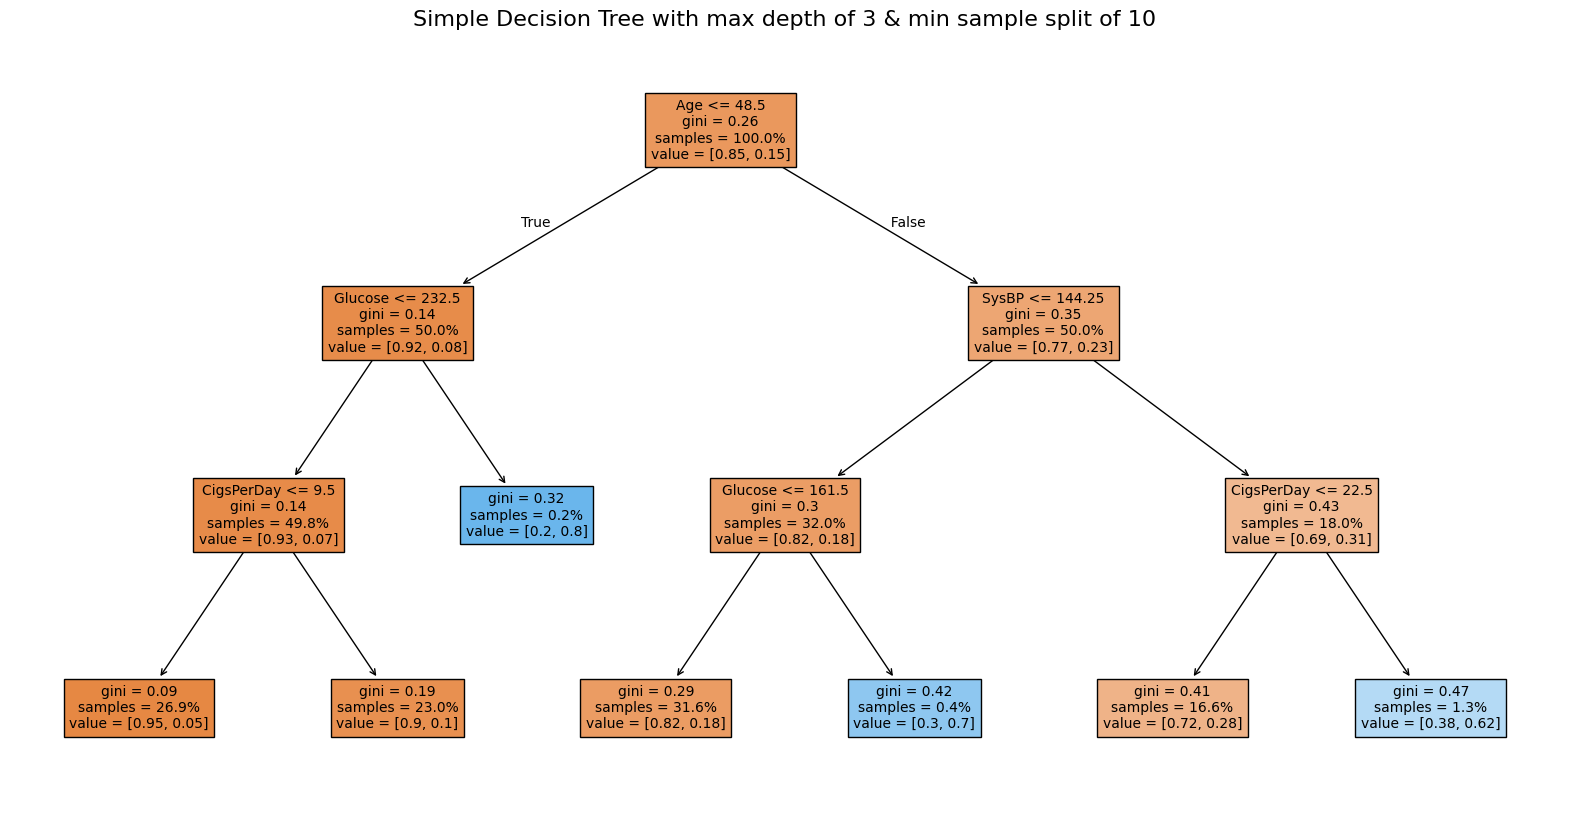

In [33]:
#Visual representation of the tree
plt.rcParams['figure.figsize'] = (20,10)
plot_tree(Dt_simple, feature_names=Dt_simple.feature_names_in_, filled=True, fontsize=10, proportion=True, precision=2)
plt.title('Simple Decision Tree with max depth of 3 & min sample split of 10', fontsize=16)
plt.show()

In [34]:
#Computing the out-of-sample AUC with the helper function
lr_auc = compute_auc(Dt_simple, X_test, y_test)
print(f'Out-of-Sample AUC for Simple Decision Tree Model: {lr_auc}')

Out-of-Sample AUC for Simple Decision Tree Model: 0.7015185525833403


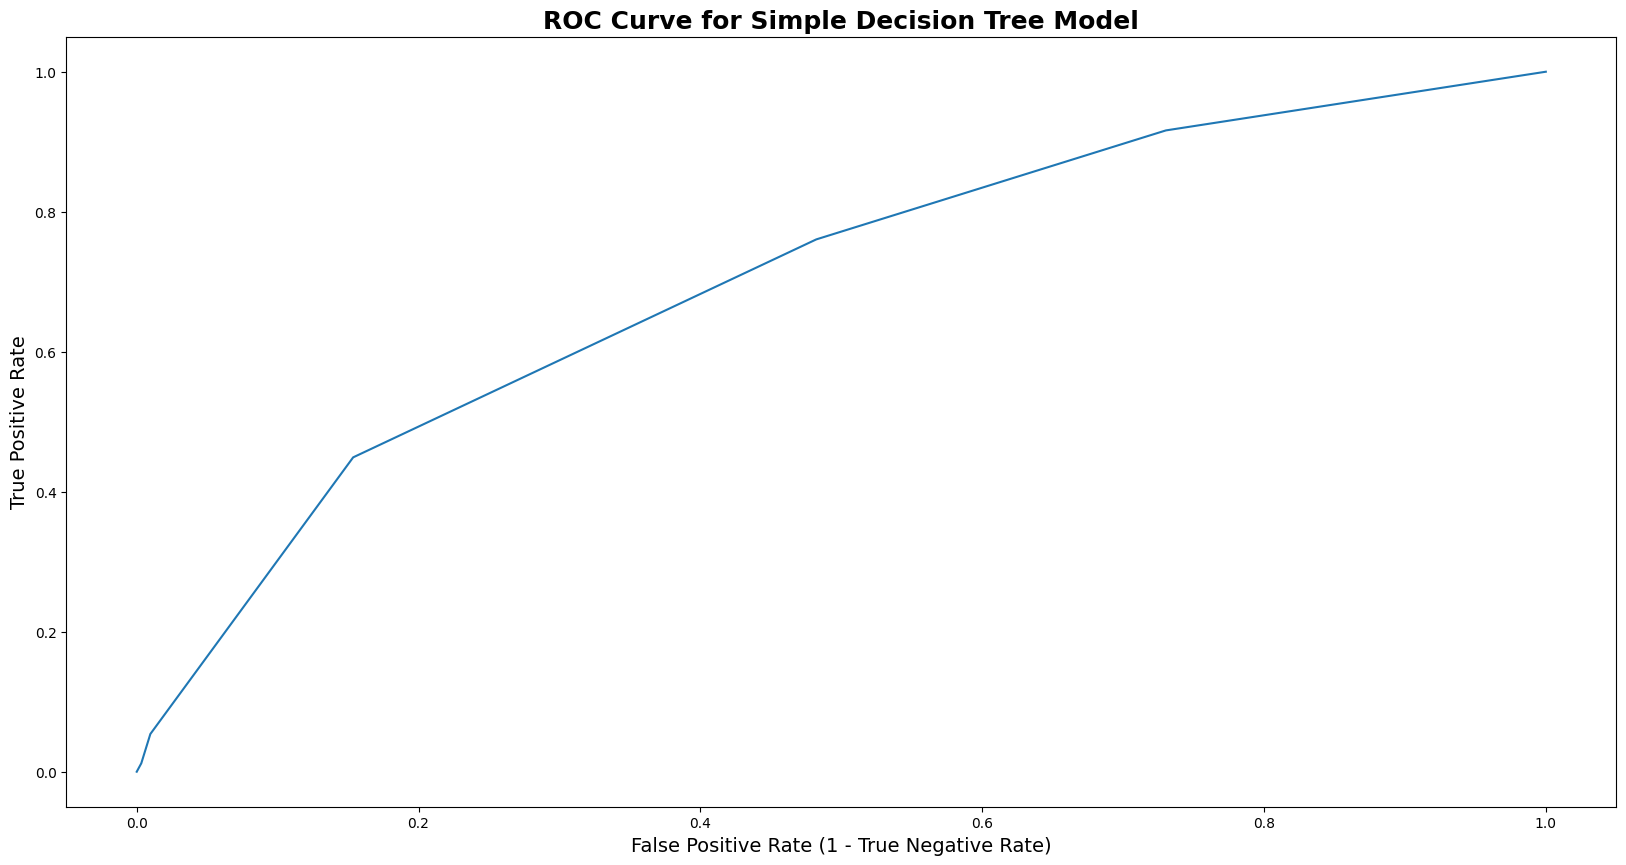

In [36]:
#creating a variable for the decision trees prediction
y_pred = Dt_simple.predict_proba(X_test)[:,1]

#plotting the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.xlabel('False Positive Rate (1 - True Negative Rate)', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve for Simple Decision Tree Model',fontweight='bold', fontsize=18)
plt.plot(fpr, tpr)

In [51]:
# creating a dataframe to display FPR, TPR and TNR
'''I will first start by creating a dataframe to inspect the roc values, include
a TNR column, which is equal to 1 - FPR, and then sort in ascending
order and pick the first row value for TPR. Notice we have a dataframe with 4
rows because of the max_depth = 3 used in the model. In python, 3 means 0-3,
representing 4 entries '''

df_roc = pd.DataFrame({
    'Threshold': thresholds,
    'FPR': fpr,
    'TPR': tpr,
    'TNR': 1 - fpr
})

# Filter rows where TNR >= 0.60 (i.e. FPR <= 0.4)
df_roc_filtered = df_roc[df_roc['TNR'] >= 0.60].sort_values(by='TPR', ascending=False)
df_roc_filtered

,Threshold,FPR,TPR,TNR
3,0.284038,0.153598,0.449102,0.846402
2,0.617647,0.009667,0.053892,0.990333
1,0.700000,0.003222,0.011976,0.996778
0,inf,0.000000,0.000000,1.000000


In [52]:
print(f'Highest achievable TPR if we require a TNR of at least 60% is {df_roc_filtered.iloc[0,2]*100}%')

Highest achievable TPR if we require a TNR of at least 60% is 44.91017964071856%
